In [1]:
from src.agent.graph import create_agent_graph
from IPython.display import Image, display

c:\university_chatbot\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
USER_AGENT environment variable not set, consider setting it to identify your requests.


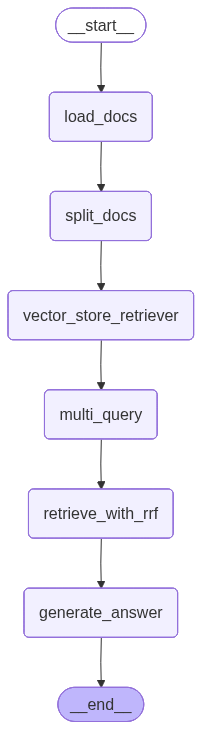

In [2]:
agent_graph = create_agent_graph()

display(Image(agent_graph.get_graph().draw_mermaid_png()))

In [3]:
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

from typing_extensions import TypedDict, Annotated, Any, List
from langchain_core.documents import Document

class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

    query: str
    queries: List[str]
    path_to_docs: str

    chunk_size: int
    chunk_overlap: int

    embed_model: str
    main_model: str
    llm: Any

    top_k_docs: int
    top_k_queries: int

    raw_docs: List[Document]
    split_docs: List[Document]
    retrieved_docs: str

    final_answer: str

init_state: State = {
    "messages": [],

    "query": "Điều kiện để được xét công nhận tốt nghiệp đại học là gì?",
    "queries": [],
    "path_to_docs": "data/raw_documents",

    "chunk_size": 500,
    "chunk_overlap": 50,

    "embed_model": "mxbai-embed-large",
    "main_model": "llama3:8b",

    "top_k_docs": 5,
    "top_k_queries": 5,

    "raw_docs": [],
    "split_docs": [],
    "retrieved_docs": "",

    "final_answer": "",
}

graph = create_agent_graph()
final_state = graph.invoke(init_state)

print(f"Final Answer: {final_state['final_answer']}")

Final Answer: answer='Để được xét công nhận tốt nghiệp đại học, sinh viên cần đáp ứng các điều kiện sau: Firstly, they must complete the required number of credits and courses as specified in their study plan. Secondly, for students who have been exempted from certain credit requirements, they need to design a learning schedule that takes into account the reduced credit load and the time it takes to complete the program. The maximum time allowed for completing the program is 3 semesters beyond the original timeline, with no more than 2 extensions. Additionally, students must meet the academic requirements set by their faculty or department, which typically involve passing a comprehensive exam, defending a thesis, or submitting a research paper. Finally, if a student fails to meet these requirements, they may need to undergo a re-examination process, which involves presenting their case to a university committee and receiving a verdict on whether their degree will be granted or not.'


In [4]:
final_state["queries"]

['Điều kiện gì về điểm trung bình chung để được xét công nhận tốt nghiệp đại học?',
 'Các điều kiện nào về tín chỉ, tín chỉ chính và tín chỉ phụ để được xét công nhận tốt nghiệp đại học?',
 'Điều kiện gì về thời gian học tập để được xét công nhận tốt nghiệp đại học?',
 'Các yêu cầu nào về luận văn, đồ án hay báo cáo để được xét công nhận tốt nghiệp đại học?',
 'Điều kiện gì về các môn học và tín chỉ cần phải có để được xét công nhận tốt nghiệp đại học?']

In [5]:
final_state["retriever"]

VectorStoreRetriever(tags=['Chroma', 'OllamaEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002212AAEECF0>, search_kwargs={'k': 5})